In [1]:
# seaborn as sns: seaborn data dekhne aur data nikalne ki library hai
import seaborn as sns
# Data ko tables (DataFrames) ki shakal mein handle karne ki sab se ahem library
import pandas as pd
# Maths aur numbers ke calculations ke liye use hoti hai. Short name np
import numpy as np

# sklearn (Scikit-Learn) machine learning ki library hai. Uske impute (missing values
# bhaarne wale) section mein se hum do tools lekar aa rahe hain: SimpleImputer aur KNNImputer
from sklearn.impute import SimpleImputer, KNNImputer

# : sns library ko hum keh rahe hain ke internet se Titanic ka mashhoor dataset 
# download kar ke df mein daal de.
df = sns.load_dataset('titanic')


# Step 1: Missing value audit

# Hum ek naya chota table bana rahe hain jiska naam humne missing rakha hai, taake
# missing data ka hisab rakh sakein.

# df.isnull() poore table mein check karta hai ke kaunsa cell khali (NaN) hai. Jahan
# khali hota hai wahan True likh deta hai.

# .sum() un sab True values ko ginta (count karta) hai. Toh yeh batata hai ke har column
# mein kitne cells khali hain.


# pct ka matlab hai Percentage (%).

# df.isnull().mean() missing values ka ratio (hissa) nikalta hai (jaise 0.20).

# * 100 usko percentage mein badalta hai (jaise 20%).

# .round(2) point ke baad sirf 2 numbers tak value ko mehdood (round off) karta hai (jaise 20.14).

# .sort_values('pct', ascending=False): Poore table ko pct (percentage) ke mutabiq tarteeb (sort) 
# karta hai. ascending=False ka matlab hai bade se chote ki taraf (highest missing values 
# sab se upar aayengi).


missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'pct': (df.isnull().mean() * 100).round(2)
}).sort_values('pct', ascending=False)

# missing['count'] > 0: Hum keh rahe hain ke is naye table mein sirf woh columns dikhao jahan missing
# values ki ginti 0 se zyada ho (yani jahan sach mein koi data missing ho).
missing = missing[missing['count'] > 0]
print(missing)

# Step 2: Drop columns with >50% missing

# Yeh function rows ya columns ko delete karne ke liye use hota hai

# thresh=len(df) * 0.5: thresh ka matlab hai Threshold (shart). len(df) ka matlab hai total rows 
# (Titanic mein 891 rows hain). * 0.5 ka matlab 50%. Yani hum keh rahe hain: "Sirf woh columns rakho 
# jinme kam az kam 50% asli data mojood ho. Agar 50% se zyada data khali hai, toh usay ura do."
# (Jaise deck column delete ho jayega kyunki usme ~77% data missing hota hai).


# axis=1: Pandas mein axis=0 ka matlab rows hota hai aur axis=1 ka matlab columns hota hai.
# Hum columns delete kar rahe hain isliye axis=1 likha.


df = df.dropna(thresh=len(df) * 0.5, axis=1)

# Step 3: Median fill for age (right-skewed)

# df['age']: Hum sirf age waale column ko target kar rahe hain.

# .fillna(...): Fill NA (Missing values ko kisi value se bhar do).

# df['age'].median(): Age column ka Median (darmiyani value) nikaal raha hai. Median isliye use kiya kyunki
# age ka data skewed (kuch log bohot bade ya chote ho sakte hain) hota hai, aur median par outliers 
# ka asar nahi hota.
df['age'].fillna(df['age'].median(), inplace=True)


# df['embarked']: Hum embarked (jahan se musafir sawar hue—C, Q, S) waale column ko target kar rahe hain.

# df['embarked'].mode()[0]: mode() ka matlab hai woh value jo sab se zyada baar aayi ho (Most frequent).
# Kyunki yeh text data hai, iska sum ya median nahi nikal sakta. [0] isliye likha kyunki mode ek list
# deta hai, aur hume uski pehli value chahiye.

# inplace=True: Asli data ke andar hi is missing value ko sab se zyada aane wale station (jo ke 'S' hai)
# se bhar do.

# Step 4: Mode fill for categorical
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


# df.select_dtypes(include='number'): Yeh command pooray table mein se sirf un columns ko chunti hai jinme 
# numbers hain (jaise fare, pclass, age). Text waale columns ko chorr deti hai.

# .columns: Un numeric columns ke naam nikal kar num_cols variable mein save kar deta hai.
# Step 5: KNNImputer comparison
num_cols = df.select_dtypes(include='number').columns

# KNNImputer(n_neighbors=5): Hum ne KNN (K-Nearest Neighbors) imputer ka ek tool taiyar kiya. Yeh tool
# missing value ko ainvayi nahi bharta, balki yeh dekhta hai ke jis bande ka data missing hai, uske
# jaisey baqi 5 musafir (n_neighbors=5) kaun se hain, aur unki values ka average nikal kar daalta hai.

knn = KNNImputer(n_neighbors=5)

# df_knn = df.copy(): Asli df ki ek duplicate copy bana kar df_knn mein rakh di taake purana data kharab na ho.
# knn.fit_transform(...): Yeh tool numeric columns par chalta hai, missing values ko dhoondhta hai, 
# unke padosi (neighbors) dekh kar unhe naye algorithm se bhar deta hai.
df_knn = df.copy()
df_knn[num_cols] = knn.fit_transform(df_knn[num_cols])


# df.isnull().sum(): Har column ke missing values ginta hai.

# .sum() (Doosra wala): Un sab columns ke missing counts ko aapas mein jama (plus) kar ke pooray table ka
# ek single total number nikalta hai.

# print(...): Kyunki humne Step 2, 3, aur 4 mein saari missing values handle kar li hain, toh screen par 
# output aayega: Missing after cleaning: 0. Yani ab aapka data bilkul saaf ho chuka hai!
print("Missing after cleaning:", df.isnull().sum().sum())

             count    pct
deck           688  77.22
age            177  19.87
embarked         2   0.22
embark_town      2   0.22
Missing after cleaning: 2


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\77877347.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\77877347.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [2]:
# TASK 2          OUTLIERS DETECTION 

Fare outliers: 116 | Range: -26.72 - 65.63


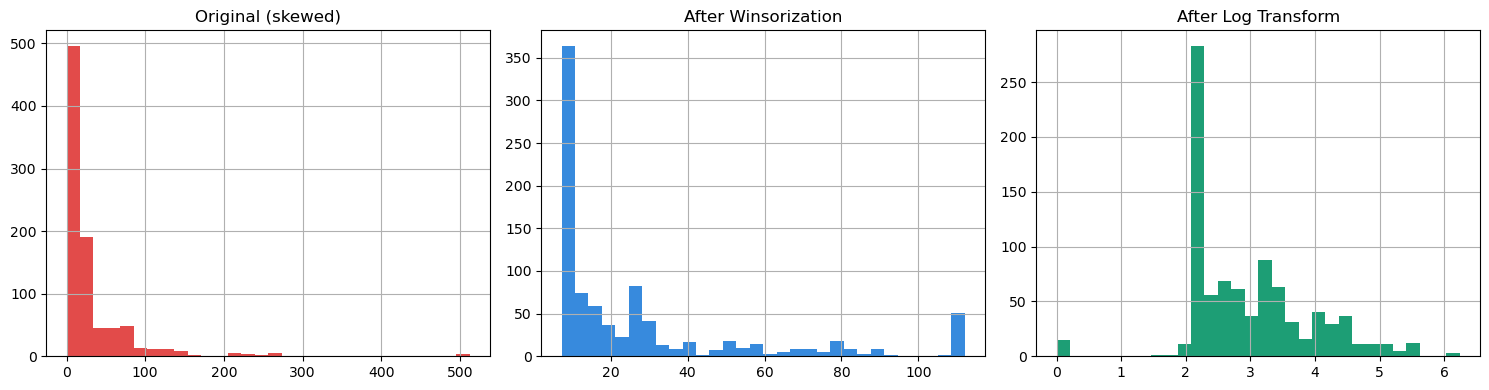

In [3]:

# scipy ek scientific calculation ki library hai. Uske stats (statistical) module ko hum lekar aa rahe hain
# (hathalaanki is specific code mein iska use nahi hua, par outliers ke liye yeh ahem hai).

# matplotlib Python mein graphs aur charts banane ki sab se purani aur mashhoor library hai.
#     plt iska short name rakha hai.


from scipy import stats
import matplotlib.pyplot as plt

# IQR outlier detection

# def: Python mein naya function banane (define karne) ke liye use hota hai.

# detect_outliers_iqr(df, col): Function ka naam hai. Yeh aapse do cheezein mangega: 
# aapka DataFrame (df) aur us column ka naam (col) jise check karna hai.


# Q1 (Quartile 1): Data ko chote se bade tarteeb mein rakh kar, shuruati 25% (pachis feesad)
# ka jo point hota hai, usay Q1 kehte hain.

# Q3 (Quartile 3): Data ka 75% (pachattar feesad) wala point. In dono ke darmiyan baqi ka 50% 
# central data hota hai.

# .quantile(0.25): Pandas ka function hai jo yeh percentile point nikal kar deta hai.

# IQR (Interquartile Range): Yeh darmiyani data ki lambai hoti hai. Q3 mein se Q1 minus kar ke aati hai.


# lower / upper: Yeh data ki do haddain (boundaries) hain. Dunya ka standard rule hai ke agar koi
# value is lower boundary se choti ho, ya upper boundary se bari ho, toh usay Outlier
# (ajeeb outlier value) mana jata hai. 1.5 ek standard multiplier hai.



# df[...]: Hum table ko filter kar rahe hain.

# |: Is pipe symbol ka matlab hota hai "OR" (ya). Yani agar column ki value lower se choti ho YA upper 
# se bari ho, toh unhe chun lo.

# return len(outliers), lower, upper: len() ka matlab hai length (ginti). Yeh function chalne ke 
# baad teen cheezein wapas karega: outliers ki ginti, choti boundary, aur bari boundary.


def detect_outliers_iqr(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper



# count, low, high = ...: Function jo teen cheezein return karega, woh in teen variables mein
# bari bari save ho jayengi. Hum 'fare' column check kar rahe hain.

# print(f"..."): f ka matlab hai formatted string. Variable ko {} ke andar likh kar print 
# kar sakte hain.

# :.2f: Ka matlab hai point ke baad sirf 2 decimal numbers tak show karo (jaise 65.63).

count, low, high = detect_outliers_iqr(df, 'fare')
print(f"Fare outliers: {count} | Range: {low:.2f} - {high:.2f}")

# Winsorization — cap at 5th and 95th percentile


# df['fare_clean']: Hum ek naya saaf suthra column bana rahe hain jiska naam rakha fare_clean.

# .clip(...): clip ka matlab hota hai kaatna ya hadd lagana.

# lower=...quantile(0.05): Jo sab se chote 5% musafir hain, unka kiraya jitna bhi kam ho, 
# usko 5th percentile par fix kar do.

# upper=...quantile(0.95): Jo sab se ameer 5% log hain (jin ka bohot zyada fare tha), un 
# sab ka fare kaat kar 95th percentile wale bande jitna kar do. Is se koi outlier data se
# delete nahi hota, bas unki extreme values thori seedhi ho jati hain.


df['fare_clean'] = df['fare'].clip(
    lower=df['fare'].quantile(0.05),
    upper=df['fare'].quantile(0.95)
)

# Log transform

# df['fare_log']: Ek aur naya column bana rahe hain jahan hum log transform apply karenge.

# p.log1p(...): numpy ka function hai jo log(x + 1) calculation karta hai. +1 isliye kiya
# jata hai taake agar kisi ka kiraya 0 ho, toh math error na aaye (kyunki log(0) output
# nahi deta, par log(1) zero hota hai). Log lene se jo bohot bari values hoti hain, 
# woh bohot choti ho jati hain aur data ka skewness (tedha-pan) kha


df['fare_log'] = np.log1p(df['fare'])

# Before vs After visualization'

# plt.subplots(1, 3, ...): Matplotlib ko bol rahe hain ke ek hi frame mein 1 row aur 3 columns
# (yani side-by-side teen graphs) ki jagah banao.

# fig, axes: fig poori tasweer hai aur axes un teen graphs ki alag alag positions hain
# (axes[0], axes[1], axes[2]).

# figsize=(15, 4): Tasweer ka size: 15 inch lambi aur 4 inch oonchi.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# .hist(...): Histogram graph banao (jo data ki distribution dikhata hai).

# ax=axes[0]: Is graph ko pehle (0 number) box mein dalo.

# bins=30: Data ko 30 bars (dandian) mein divide karo.

# color='#E24B4A': Is bar ka rang Red (laal) hoga.

# axes[0].set_title(...): Pehle graph ka naam rakh diya "Original (skewed)".

df['fare'].hist(ax=axes[0], bins=30, color='#E24B4A')
axes[0].set_title('Original (skewed)')
df['fare_clean'].hist(ax=axes[1], bins=30, color='#378ADD')
axes[1].set_title('After Winsorization')
df['fare_log'].hist(ax=axes[2], bins=30, color='#1D9E75')
axes[2].set_title('After Log Transform')

# plt.tight_layout(): Graphs ko aapas mein takrane se rokhta hai aur unhe sahi space deta hai.

# plt.savefig('...', dpi=200): Is pooray graph ki tasweer ko aap ke computer mein outlier_treatment.png
# ke naam se save kar dega. dpi=200 se photo saaf aur high quality aayegi.

# plt.show(): Screen par tasweer show kar do!
plt.tight_layout()
plt.savefig('outlier_treatment.png', dpi=200)
plt.show()

In [4]:
#TASK 3    INCONSISTENT DATA 

In [5]:
# Create messy data — common real client scenario


# name: Alice ke shuru mein space hai, BOB bade harfo mein hai, Charlie ke aakhir mein space hai. 
# (Halaanki Alice aur Bob duplicate hain, par computer unhe alag samajh raha hai).

# city: New York ko alag alag tareeqon se likha gaya hai (NY, NYC, new york).

# salary: Kahin $ aur comma , laga hai, kahin simple number text ki shakal mein hai.

# age: Charlie ki umer 999 likhi hai jo ke namumkin hai (outlier/typo).

# date: Ek hi tareekh ko teen alag formats mein likha gaya hai.

# pd.DataFrame(messy_data): Is poore data ko Pandas ke ek proper table (DataFrame) mein badal kar
# df_messy naam ke variable mein save kar diya.

messy_data = {
    'name':   ['  Alice', 'BOB', 'alice', 'Charlie ', 'Bob'],
    'city':   ['New York', 'NY', 'new york', 'Chicago', 'NYC'],
    'salary': ['$50,000', '60000', '50000', '$75,000', '60000'],
    'age':    [25, 30, 25, 999, 30],
    'date':   ['2024-01-15', '15/01/2024', 'Jan 15 2024', '2024-04-20', '2024-01-15']
}
df_messy = pd.DataFrame(messy_data)


# Fix strings

# .str: Pandas ko batata hai ke hum text (string) par koi operation karne lage hain.

# .strip(): Naam ke shuru aur aakhir mein jo faltu khali jagah (extra spaces) hain, unhe khatam (delete) kar deta hai.

# .title(): Pehla akshar bada (Capital) aur baqi chote kar deta hai. (Jaise '  Alice' aur 'alice' dono badal kar 
# 'Alice' ho jayenge, aur 'BOB' badal kar 'Bob').


# .lower(): Sheher ke tamam harfo ko choti ABC (lowercase) mein badal deta hai. (Jaise 'New York' badal kar 
# 'new york' ho jayega).

df_messy['name'] = df_messy['name'].str.strip().str.title()
df_messy['city'] = df_messy['city'].str.strip().str.lower()
df_messy['city'].replace({'ny': 'new york', 'nyc': 'new york'}, inplace=True)

# Fix data types

# .replace({...}): Yeh ek dictionary leta hai jiska matlab hai: "Jahan jahan ny ya nyc likha nazar aaye, usay
# badal kar poora new york likh do."

# inplace=True: Yeh tabdeeli isi table ke andar fix kar do.

# str.replace('[$,]', '', regex=True):

# [$,] ka matlab hai ke dollar sign $ ya comma , jahan bhi ho.

# '' (khali string) ka matlab hai unhe delete kar do.

# regex=True Pandas ko batata hai ke hum symbols ko dhoondhne ke liye Regular Expression (pattern) use kar 
# rahe hain. (Jaise '$50,000' badal kar '50000' reh jayega).

# .astype(float): Kyunki salary abhi tak text (string) thi, is command se computer usay point wale number 
# (float) mein badal deta hai taake hum is par maths apply kar sakein.


df_messy['salary'] = df_messy['salary'].str.replace('[$,]', '', regex=True).astype(float)


# pd.to_datetime(...): Yeh Pandas ka bohot aqalmand tool hai jo text ko proper Date format (YYYY-MM-DD) mein badalta hai.

# infer_datetime_format=True: Computer ko ijazat deta hai ke woh khud andaza lagaye ke tareekh kis format mein likhi hai 
#  (chahe woh Jan 15 ho ya 15/01).
# errors='coerce': Agar koi tareekh aisi ho jo bilkul hi samajh na aaye (jaise koi ghalat spelling), toh error dene ki bajaye
# wahan NaT (Not a Time / khali cell) likh do taake code ruke na.




df_messy['date']   = pd.to_datetime(df_messy['date'], infer_datetime_format=True, errors='coerce')

# Fix outliers in age

# .between(0, 120): Shart lagata hai ke umer 0 se 120 saal ke darmiyan honi chahiye.

# .where(...): Yeh shart check karta hai. Agar umer is hadd ke andar hai, toh usay waisa hi chor deta hai. Agar hadd se baahir
# hai (jaise Charlie ki umer 999 hai), toh usay badal kar np.nan (NaNyani missing value) bana deta hai.


df_messy['age'] = df_messy['age'].where(df_messy['age'].between(0, 120), np.nan)
# Remove duplicates

# df_messy.drop_duplicates(...): Faltu (ek jaisi double) rows ko delete karne ke liye.

# subset=['name', 'city']: Hum computer ko keh rahe hain ke agar kisi row mein name aur city dono bilkul match kar jayein,
# toh us row ko duplicate samjho aur delete kar do. Is saaf data ko humne df_clean variable mein rakh diya.


# df_clean = df_messy.drop_duplicates(subset=['name', 'city'])

# len(df_messy): Purane table ki rows ginta hai (jo ke 5 thin).

# len(df_clean): Naye saaf table ki rows ginta hai (jo ke duplicate delete hone ke baad kam ho jayengi).

# print(df_clean): Aakhir mein bilkul saaf suthra table screen par dikha deta hai jisme saare naam seedhe hain, sheher aik jaise
# hain, umer thik hai, aur numbers proper format mein hain!



print("Before:", len(df_messy), "rows")
print("After:", len(df_clean), "rows")
print(df_clean)

Before: 5 rows
After: 3 rows
      name      city   salary   age       date
0    Alice  new york  50000.0  25.0 2024-01-15
1      Bob  new york  60000.0  30.0        NaT
3  Charlie   chicago  75000.0   NaN 2024-04-20


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\1667494688.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_messy['city'].replace({'ny': 'new york', 'nyc': 'new york'}, inplace=True)
C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\1667494688.py:18: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argumen

In [6]:
# TASK 4  Complete data cleaning pipeline

In [7]:
# def: Python mein function banane (define karne) ke liye use hota hai.

# clean_dataframe(...): Yeh is function ka naam hai.

# df: Yeh pehla input parameter hai, yani aapka ganda dataset (DataFrame).

# target_col=None: Yeh doosra parameter hai. Machine learning mein ek target variable hota hai jise 
# model predict karta hai (jaise Titanic mein survived). Hum None likh kar computer ko keh rahe hain 
# ke agar user koi target column na bhi bataye, toh code kharab na ho.



# """...""": Ise Docstring kehte hain. Yeh sirf insano ke parhne ke liye ek note hota hai ke yeh function kya karta hai.


# report = {}: Humne ek khali dictionary banayi hai jiska naam report rakha hai. Isme hum saari safai ka record 
# (jaise kitne columns uraaye, kitne duplicates khatam kiye) save karenge.


# df_clean = df.copy(): Asli data ko kharab hone se bachane ke liye humne uski ek duplicate copy banayi aur usay 
# df_clean naam de diya. Ab saari safai is copy par hogi.

# initial_rows = len(df_clean): Shuruat mein data mein kitni rows (records) thin, unki ginti humne initial_rows
# variable mein save kar li.


def clean_dataframe(df, target_col=None):
    """Professional data cleaning pipeline — client deliverable"""
    report = {}
    df_clean = df.copy()
    initial_rows = len(df_clean)

    
    # 1. Drop high-missing columns (>50%)
#  df_clean.isnull().mean(): Har column mein check karta hai ke kitne feesad (percentage)
# data missing hai (jaise 0.70 ka matlab 70%).

# > 0.5: Shart lagata hai ke jin columns mein 50% se zyada data missing ho.

# df_clean.columns[...]: Un columns ke naam nikal kar high_missing variable mein save kar deta
# hai (Titanic mein deck column yahan select ho jayega). 

# .drop(columns=..., inplace=True): high_missing mein jo columns aaye the, unhe table se hamesha 
# ke liye delete (drop) kar do.

# report['columns_dropped'] = list(high_missing): Hamari report wali dictionary mein ek naya khata
# (key) kholo aur usme un columns ke naam likh lo jo humne delete kiye hain, taake client ko pata chale.  

    
    high_missing = df_clean.columns[df_clean.isnull().mean() > 0.5]
    df_clean.drop(columns=high_missing, inplace=True)
    report['columns_dropped'] = list(high_missing)


#     for col in df_clean.select_dtypes(include='number').columns: Yeh loop pooray table mein se sirf numeric 
#     (numbers wale) columns ko ek ek karke chunta hai.

# if col != target_col: Yeh ek safety check hai. Hum keh rahe hain: "Agar yeh column hamara main target variable
# (survived) hai, toh isko mat chero." Target variable ko khud se guess karke bharna ghalat hota hai.

# .fillna(..., median()): Agar target ke alawa koi number wala column khali hai (jaise age), toh usay us column 
# ki darmiyani value (Median) se bhar do.



    
    # 2. Fill remaining missing values


# select_dtypes(include='object'): Yeh loop sirf text (categorical) columns par chalta hai (jaise embarked).

# df_clean[col].mode()[0]: Agar us column mein koi value sab se zyada baar aayi hai (Mode), toh missing cell
# ko us value se bhar do.

# if not ... else 'Unknown': Agar khuda-na-khwasta poora column hi khali ho aur koi mode na nikal raha ho, 
# toh wahan ghalat value bharne ki bajaye 'Unknown' (na-maloom) likh do.   


    for col in df_clean.select_dtypes(include='number').columns:
        if col != target_col:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
    for col in df_clean.select_dtypes(include='object').columns:
        df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty
                            else 'Unknown', inplace=True)


# df_clean.drop_duplicates(inplace=True): Agar table mein bilkul ek jaisi rows baar baar aayi hain, toh faltu rows 
# ko delete kar do aur sirf ek asli row choro.

# initial_rows - len(df_clean): Shuruati rows mein se ab ki bachi hui rows minus (kam) kar do. Is se pata chal 
# jayega ke computer ne total kitni duplicate rows delete keen, aur us ginti ko humne report mein save kar liya.



    # 3. Remove duplicates
    df_clean.drop_duplicates(inplace=True)
    report['duplicates_removed'] = initial_rows - len(df_clean)
    
    # 4. Data quality score

# missing_pct: Asli (gande) data mein total kitne percent cells khali the.

# dup_pct: Asli data mein kitne percent duplicate rows thin.

# before_score: 100 number mein se missing aur duplicate ki percentage ka aadha (*0.5) minus kar ke shuruati score
# nikaal rahe hain. max(0, ...) isliye ke score kabhi minus mein na chala jaye.


    missing_pct  = df.isnull().mean().mean() * 100
    dup_pct      = df.duplicated().mean() * 100
    before_score = max(0, 100 - missing_pct*0.5 - dup_pct*0.5)


# after_score: Safai ke baad kyunki hum saari missing values bhar chuke hain, toh yeh score 100.0 (perfect) aayega.

# round(..., 1): Score ko point ke baad sirf ek number tak mehdood (round) kar raha hai (jaise 85.5). In sab ko 
# report mein save kar diya.

    after_score  = 100 - df_clean.isnull().mean().mean()*100

    report['quality_score_before'] = round(before_score, 1)
    report['quality_score_after']  = round(after_score, 1)


# Safai se pehle kitni rows thin (rows_before) aur ab kitni bachi hain (rows_after), yeh bhi report mein likh diya.

    report['rows_before'] = initial_rows
    report['rows_after']  = len(df_clean)

    print("=== DATA CLEANING REPORT ===")

# or k, v in report.items():: Yeh loop hamari report dictionary ke andar jata hai aur uski har Key 
# (k, jaise rows_before) aur Value (v, jaise 891) ko bari bari nikalta hai.

# print(...): Unhe screen par khoobsurat tareeqe se print kar deta hai.

# return df_clean, report: Jab yeh function apna kaam khatam karega, toh yeh hume do cheezein tohfe mein wapas dega: 
# bilkul saaf suthra naya DataFrame (df_clean) aur poori safai ki details (report).


    for k, v in report.items():
        print(f"  {k}: {v}")

    return df_clean, report
# Use it


# Hum ne apne banaye hue clean_dataframe function ko awaz di. Usay input mein Seaborn se download kiya hua Titanic
# data diya aur bataya ke hamara target column 'survived' hai. Function chala, usne screen par puri report print 
# ki, aur saaf data df_clean variable mein daal diya.


df_clean, report = clean_dataframe(sns.load_dataset('titanic'), target_col='survived')


# .to_csv('...', index=False): Yeh Pandas ka function hai jo is saaf suthre table ko aap ke computer mein 
# titanic_cleaned.csv ke naam se ek Excel/CSV file bana kar save kar deta hai.

# index=False: Iska matlab hai ke Pandas ki apni jo 0, 1, 2, 3 wali counting (index) hoti hai, usay file mein save 
# mat karo, sirf asli columns save karo.


df_clean.to_csv('titanic_cleaned.csv', index=False)

=== DATA CLEANING REPORT ===
  columns_dropped: ['deck']
  duplicates_removed: 116
  quality_score_before: 90.7
  quality_score_after: 100.0
  rows_before: 891
  rows_after: 775


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\3121683527.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_14068\3121683527.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh